# EDA — Irrigation Need Prediction

## Objective
The goal of this analysis is to understand the dataset and identify key patterns that will guide feature engineering and model development.

**Dataset**: Kaggle competition: Playground Series S6E4 - train.csv

## Approach
- Data structure analysis
- Target variable analysis
- Missing values
- Feature distributions
- Relationships between variables

## 1. Initial Data Exploration

In [23]:
# Carga de dataset "train.csv"
import pandas as pd
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/train.csv")
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [24]:
df.info()
df.describe().round(2)


<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00
mean,314999.50,6.48,37.30,0.92,1.74,27.00,61.56,1462.21,7.51,10.38,7.52,62.32
std,181865.48,0.92,16.38,0.37,0.95,8.62,19.71,612.99,2.00,5.69,4.22,34.25
min,0.00,4.80,8.00,0.30,0.10,12.00,25.00,0.38,4.00,0.50,0.30,0.02
25%,157499.75,5.69,23.34,0.61,0.93,19.52,45.39,954.57,5.76,5.28,3.88,33.14
50%,314999.50,6.44,37.75,0.91,1.74,26.96,61.65,1467.16,7.58,10.48,7.38,61.15
75%,472499.25,7.27,51.27,1.22,2.58,34.54,79.12,2054.28,9.25,15.43,11.14,92.69
max,629999.00,8.20,64.99,1.60,3.50,42.00,94.99,2499.69,11.00,20.00,15.00,119.99


No nulls. 
Is a clean dataset with 21 columns 12 numeric and 9 categorical. (probably an artificial dataset due to the nature of the competition).

### Remember
- **Desviación estándar** (std): measure the variation or dispersion of a set of values. Close to mean or far from it. 
- **Quartiles**: values are divide in equal parts. The 25% of the data is below the Q1 number, and so on. 
- **Asymetry**: if the mean and the mediar are close is symmetris, asymetric if they are not.

### Visualization target objetive "irrigation_need". 
It has 3 values low, medium and high. 

| Probably would be interesting to transform into numerical variable. 


In [29]:
df["Irrigation_Need"].describe()


count     630000
unique         3
top          Low
freq      369917
Name: Irrigation_Need, dtype: object

<Axes: >

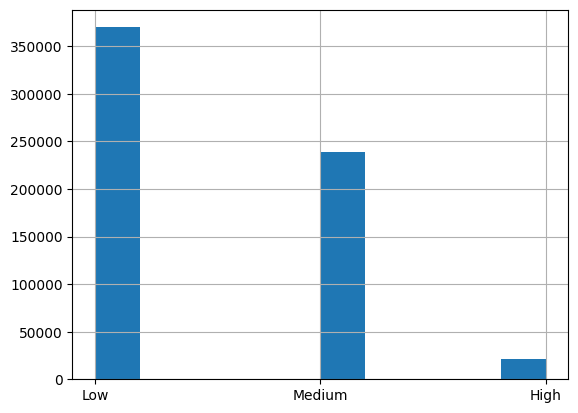

In [30]:
df["Irrigation_Need"].hist()
